# 🌍 05 — Cluster Profiling
### World Development Clustering Pipeline

---

**Purpose:** Deep interpretation of all 5 model clusters — mirrors `assign_cluster_labels()`, `cluster_profile()`, `validate_clusters_gdp_proxy()`, and Stage 9 of `training_pipeline.py`.  
**Input:** `data/processed/final_features.csv`, `data/processed/final_clustered_data.csv`, `data/processed/cleaned_data.csv`, `models/*.pkl`  
**Output:** `reports/cluster_profiles_*.csv`, human-readable labels (Developed / Developing / Underdeveloped), radar charts, world maps, country lists

---

### 🗺️ Notebook Roadmap
| Section | Description |
|---------|-------------|
| 1 | Environment Setup |
| 2 | Load Models + Assign All Cluster Labels |
| 3 | Composite Development Score → Human-readable Labels |
| 4 | Cluster Profiles — Mean Feature Heatmap |
| 5 | Radar Charts per Cluster |
| 6 | Country Lists per Cluster (all 5 models) |
| 7 | PCA 2D Scatter with Labels |
| 8 | Agreement Analysis — How Often Do Models Agree? |
| 9 | World Map Visualization |
| 10 | Final Report Summary |

---
## 1. Environment Setup

In [1]:
import os
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from math import pi
from IPython.display import display, HTML

from config.config import (
    CLEANED_DATA, CLUSTERED_DATA, REPORTS_DIR, MODELS_DIR,
    PROCESSED_DIR, ID_COL,
)
from src.utils.helpers import get_numeric_feature_cols

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})
PALETTE      = sns.color_palette('tab10')
LABEL_COLORS = {'Developed': '#2ca02c', 'Developing': '#1f77b4', 'Underdeveloped': '#d62728'}
os.makedirs(REPORTS_DIR, exist_ok=True)

print('✅ Environment ready')

✅ Environment ready


---
## 2. Load Models + Assign All Cluster Labels

In [2]:
# ── Load final feature matrix ─────────────────────────────────────────────────
FINAL_FEATURES_PATH = os.path.join(PROCESSED_DIR, 'final_features.csv')
df = pd.read_csv(FINAL_FEATURES_PATH)

_LABEL_COLS = {'KMeans_Cluster','Hierarchical_Cluster','GMM_Cluster',
               'Spectral_Cluster','Birch_Cluster','GMM_Confidence'}
feat_cols   = [c for c in df.select_dtypes(include='number').columns if c not in _LABEL_COLS]
X           = df[feat_cols].values
countries   = df[ID_COL].values if ID_COL in df.columns else np.arange(len(df))

print(f'Feature matrix: {X.shape}  |  Countries: {len(countries)}')

# ── Load models ───────────────────────────────────────────────────────────────
def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

km_model       = load_pkl(os.path.join(MODELS_DIR, 'kmeans_model.pkl'))
gmm_model      = joblib.load(os.path.join(MODELS_DIR, 'gmm_model.pkl')) if os.path.exists(os.path.join(MODELS_DIR, 'gmm_model.pkl')) else None
hc_model       = load_pkl(os.path.join(MODELS_DIR, 'hierarchical_model.pkl'))
spectral_model = load_pkl(os.path.join(MODELS_DIR, 'spectral_model.pkl'))
birch_model    = load_pkl(os.path.join(MODELS_DIR, 'birch_model.pkl'))

# ── Assign cluster labels to dataframe ───────────────────────────────────────
df_out = df.copy()
if km_model:       df_out['KMeans_Cluster']       = km_model.predict(X)
if gmm_model:      df_out['GMM_Cluster']           = gmm_model.predict(X)
if hc_model:       df_out['Hierarchical_Cluster']  = hc_model.labels_
if spectral_model: df_out['Spectral_Cluster']      = spectral_model.labels_
if birch_model:    df_out['Birch_Cluster']          = birch_model.labels_

CLUSTER_COLS = [c for c in ['KMeans_Cluster','GMM_Cluster','Hierarchical_Cluster',
                              'Spectral_Cluster','Birch_Cluster'] if c in df_out.columns]
print(f'Cluster columns assigned: {CLUSTER_COLS}')
display(df_out[[ID_COL] + CLUSTER_COLS].head(6))

Feature matrix: (198, 20)  |  Countries: 198
Cluster columns assigned: ['KMeans_Cluster', 'GMM_Cluster', 'Hierarchical_Cluster', 'Spectral_Cluster', 'Birch_Cluster']


,Country,KMeans_Cluster,GMM_Cluster,Hierarchical_Cluster,Spectral_Cluster,Birch_Cluster
0,Afghanistan,1,2,0,1,1
1,Albania,0,0,2,0,0
2,Algeria,2,1,2,2,0
3,Andorra,0,3,2,0,0
4,Angola,1,2,0,1,1
5,Antigua and Barbuda,0,0,2,0,0


---
## 3. Composite Development Score → Human-Readable Labels

> **Method (mirrors `assign_cluster_labels()` in `cluster_evaluator.py`):**  
> 1. Join cluster assignments with original-scale cleaned data  
> 2. Compute composite score per cluster using 4 features: GDP, Life Expectancy Female, Internet Usage, Infant Mortality Rate (inverted)  
> 3. Normalize each feature to [0,1] range for fair weighting  
> 4. Rank clusters by composite score → assign Developed / Developing / Underdeveloped

In [3]:
# ── Load original-scale cleaned data ─────────────────────────────────────────
df_cleaned = pd.read_csv(CLEANED_DATA)
print(f'Cleaned data shape: {df_cleaned.shape}')

SCORE_FEATURES = {
    'GDP'                   : ('higher_better', 1.0),
    'Life Expectancy Female': ('higher_better', 1.0),
    'Internet Usage'        : ('higher_better', 1.0),
    'Infant Mortality Rate' : ('lower_better',  1.0),
}
available_score_feats = [f for f in SCORE_FEATURES if f in df_cleaned.columns]
print(f'Score features available: {available_score_feats}')

def assign_labels_for_col(df_out, cluster_col, df_cleaned, id_col=ID_COL):
    """Mirrors cluster_evaluator.assign_cluster_labels() exactly."""
    label_col = f'{cluster_col}_Label'
    merge_cols = [id_col] + available_score_feats
    df_merge = df_out[[id_col, cluster_col]].merge(
        df_cleaned[merge_cols], on=id_col, how='left'
    )

    # Normalize to [0,1]
    df_norm = df_merge.copy()
    for feat in available_score_feats:
        col_data = df_norm[feat]
        rng = col_data.max() - col_data.min()
        df_norm[feat] = (col_data - col_data.min()) / rng if rng != 0 else 0.5

    # Composite score
    df_norm['_composite'] = 0.0
    for feat in available_score_feats:
        direction, weight = SCORE_FEATURES[feat]
        if direction == 'lower_better':
            df_norm['_composite'] += weight * (1.0 - df_norm[feat])
        else:
            df_norm['_composite'] += weight * df_norm[feat]

    cluster_scores = df_norm.groupby(cluster_col)['_composite'].mean().sort_values()
    n_clusters = len(cluster_scores)

    label_map = {}
    if n_clusters <= 1:
        label_map = {c: 'Developing' for c in cluster_scores.index}
    elif n_clusters == 2:
        label_map[cluster_scores.index[0]] = 'Underdeveloped'
        label_map[cluster_scores.index[1]] = 'Developed'
    elif n_clusters == 3:
        label_map[cluster_scores.index[0]] = 'Underdeveloped'
        label_map[cluster_scores.index[1]] = 'Developing'
        label_map[cluster_scores.index[2]] = 'Developed'
    else:
        sorted_c = cluster_scores.index.tolist()
        third    = max(1, n_clusters // 3)
        for i, c in enumerate(sorted_c):
            if i < third:
                label_map[c] = 'Underdeveloped'
            elif i >= n_clusters - third:
                label_map[c] = 'Developed'
            else:
                label_map[c] = 'Developing'

    df_out = df_out.copy()
    df_out[label_col] = df_out[cluster_col].map(label_map)
    return df_out, label_map, cluster_scores

# ── Apply to all 5 cluster columns ───────────────────────────────────────────
label_maps    = {}
score_maps    = {}
for col in CLUSTER_COLS:
    df_out, lmap, scores = assign_labels_for_col(df_out, col, df_cleaned)
    label_maps[col] = lmap
    score_maps[col] = scores
    label_col = f'{col}_Label'
    print(f'\n{col}:')
    for cluster_id, label in sorted(lmap.items()):
        count = int((df_out[col] == cluster_id).sum())
        score = scores.get(cluster_id, np.nan)
        print(f'  Cluster {cluster_id} → {label:<15} | composite_score={score:.3f} | n={count}')

Cleaned data shape: (208, 28)
Score features available: ['GDP', 'Life Expectancy Female', 'Internet Usage', 'Infant Mortality Rate']

KMeans_Cluster:
  Cluster 0 → Developing      | composite_score=1.978 | n=72
  Cluster 1 → Underdeveloped  | composite_score=0.937 | n=67
  Cluster 2 → Developing      | composite_score=1.807 | n=31
  Cluster 3 → Developed       | composite_score=2.742 | n=28

GMM_Cluster:
  Cluster 0 → Developing      | composite_score=1.970 | n=49
  Cluster 1 → Developing      | composite_score=1.717 | n=47
  Cluster 2 → Underdeveloped  | composite_score=0.890 | n=62
  Cluster 3 → Developed       | composite_score=2.643 | n=40

Hierarchical_Cluster:
  Cluster 0 → Developing      | composite_score=0.899 | n=61
  Cluster 1 → Underdeveloped  | composite_score=0.690 | n=2
  Cluster 2 → Developed       | composite_score=2.100 | n=133
  Cluster 3 → Developing      | composite_score=1.987 | n=2

Spectral_Cluster:
  Cluster 0 → Developing      | composite_score=1.976 | n=79
  

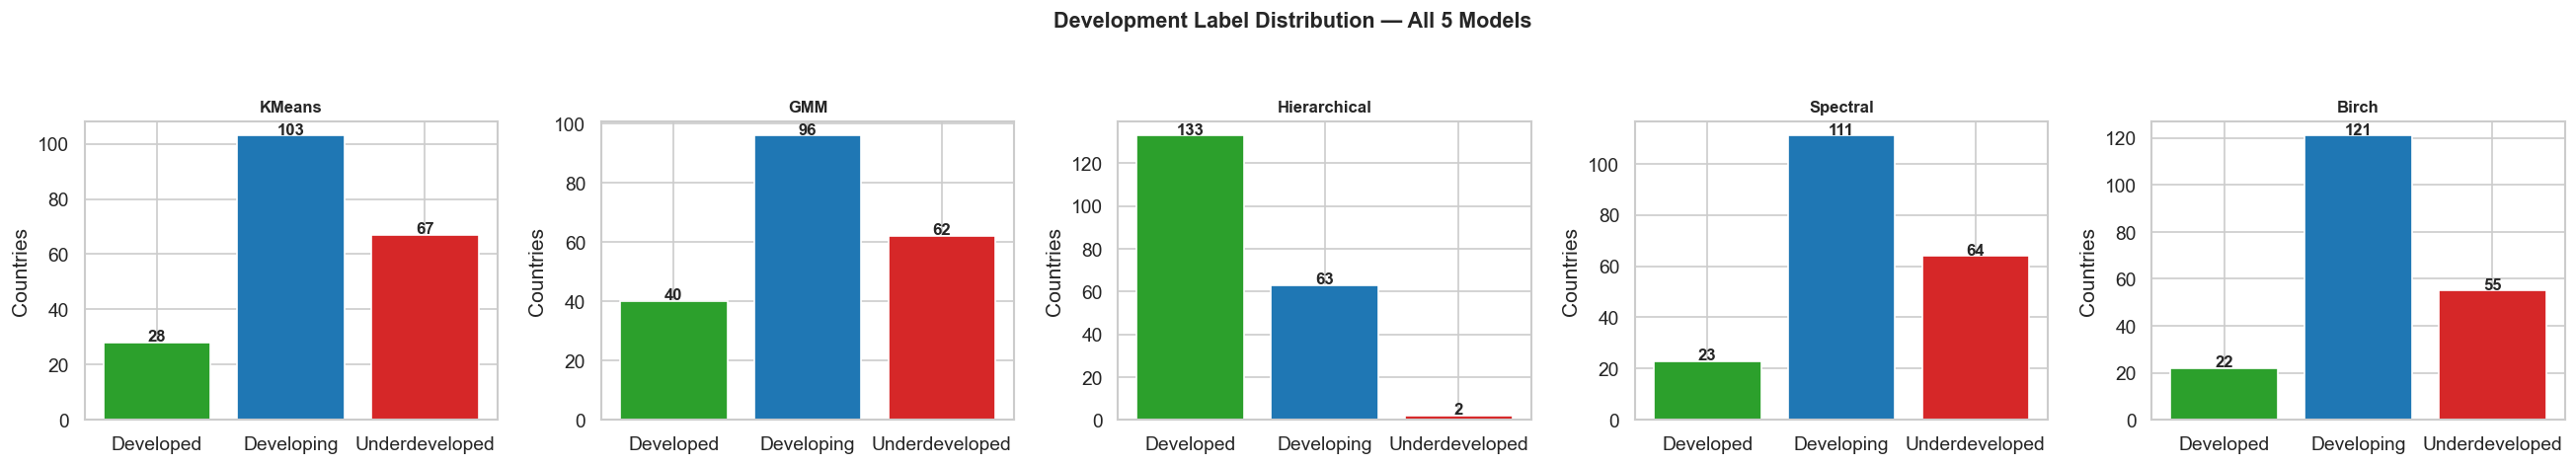

In [4]:
# ── Label distribution bar charts (all 5 models) ─────────────────────────────
LABEL_ORDER = ['Developed', 'Developing', 'Underdeveloped']

fig, axes = plt.subplots(1, len(CLUSTER_COLS), figsize=(22, 4))
if len(CLUSTER_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, CLUSTER_COLS):
    label_col  = f'{col}_Label'
    counts     = df_out[label_col].value_counts()
    bars_order = [l for l in LABEL_ORDER if l in counts.index]
    bar_vals   = [counts.get(l, 0) for l in bars_order]
    bar_colors = [LABEL_COLORS.get(l, '#888') for l in bars_order]

    ax.bar(bars_order, bar_vals, color=bar_colors, edgecolor='white')
    ax.set_title(col.replace('_Cluster', ''), fontweight='bold', fontsize=10)
    ax.set_ylabel('Countries')
    for i, v in enumerate(bar_vals):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Development Label Distribution — All 5 Models', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

---
## 4. Cluster Profiles — Mean Feature Heatmap

✅ Cluster profiles saved for: ['KMeans_Cluster', 'GMM_Cluster', 'Hierarchical_Cluster', 'Spectral_Cluster', 'Birch_Cluster']
Best model from eval: KMeans → column: KMeans_Cluster


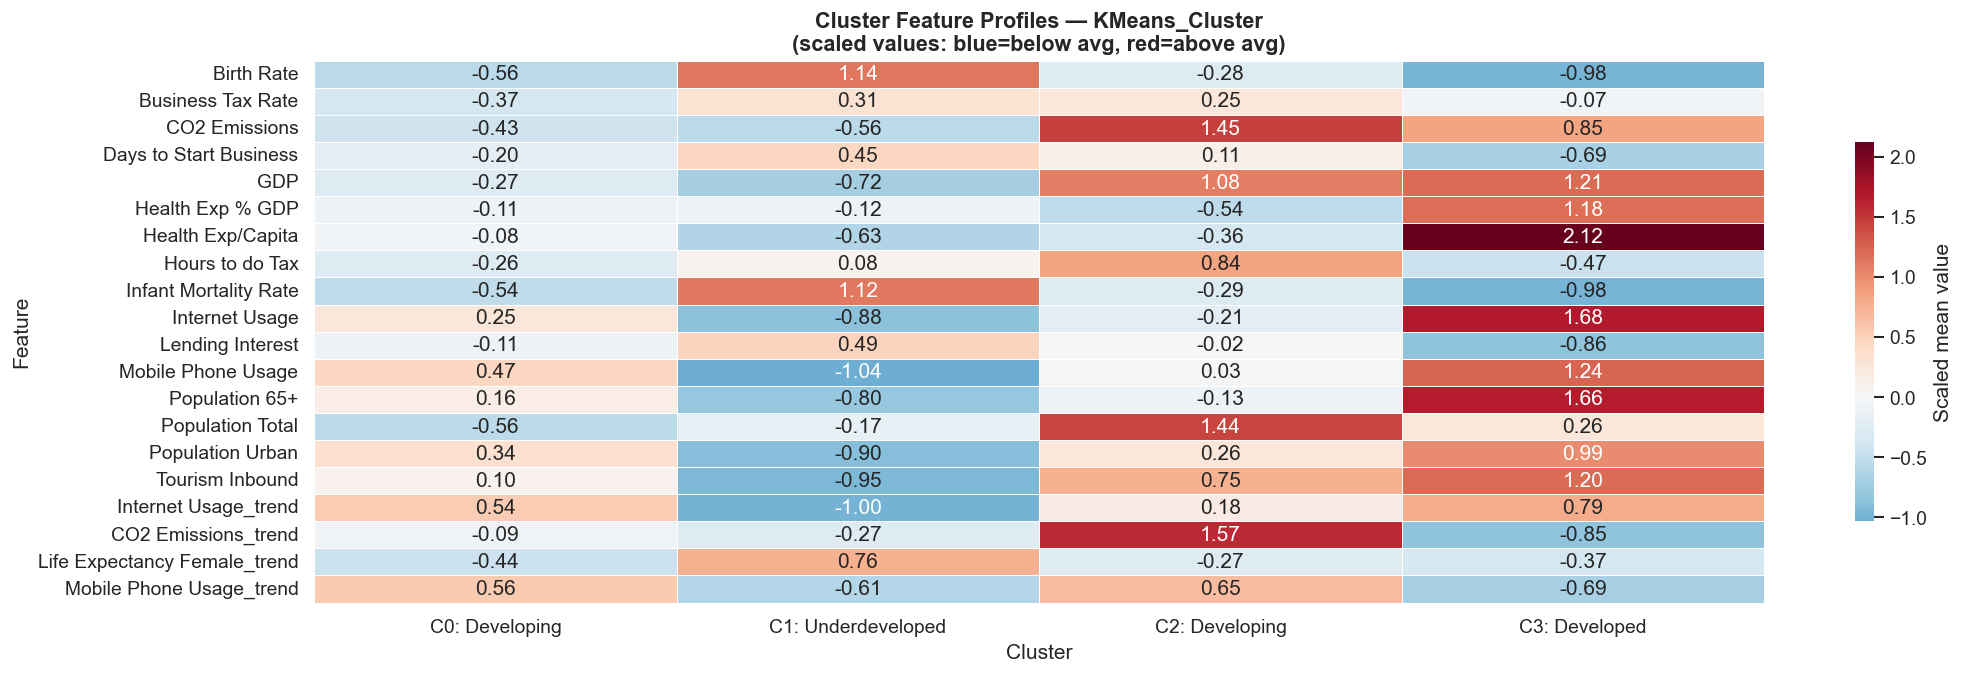

In [5]:
# ── Compute and save cluster profiles (mirrors cluster_profile() in evaluator) ─
profile_dfs = {}

for col in CLUSTER_COLS:
    profile = df_out.groupby(col)[feat_cols].mean().round(4)
    out_path = os.path.join(REPORTS_DIR, f'cluster_profiles_{col}.csv')
    profile.to_csv(out_path)
    profile_dfs[col] = profile

print(f'✅ Cluster profiles saved for: {list(profile_dfs.keys())}')

# ── Heatmap for best model ────────────────────────────────────────────────────
# Detect best model from evaluation_metrics.json if available
import json
metrics_path = os.path.join(REPORTS_DIR, 'evaluation_metrics.json')
best_col = CLUSTER_COLS[0]  # fallback

if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        eval_data = json.load(f)
    eval_df   = pd.DataFrame(eval_data)
    if 'silhouette_score' in eval_df.columns:
        valid_eval = eval_df[~eval_df.get('invalid', pd.Series([False]*len(eval_df))).fillna(False)]
        if not valid_eval.empty:
            best_model_name = valid_eval.sort_values('silhouette_score', ascending=False).iloc[0]['model']
            _M2C = {'KMeans':'KMeans_Cluster','Agglomerative':'Hierarchical_Cluster',
                    'Spectral':'Spectral_Cluster','BIRCH':'Birch_Cluster'}
            best_col = _M2C.get(best_model_name, 'GMM_Cluster')
            if 'GMM' in best_model_name:
                best_col = 'GMM_Cluster'
            if best_col not in profile_dfs:
                best_col = CLUSTER_COLS[0]
            print(f'Best model from eval: {best_model_name} → column: {best_col}')

# ── Heatmap — all features per cluster ───────────────────────────────────────
profile_best = profile_dfs[best_col]

# Add label annotation
cluster_label_map = label_maps.get(best_col, {})
profile_best.index = [
    f'C{i}: {cluster_label_map.get(i, str(i))}' for i in profile_best.index
]

fig, ax = plt.subplots(figsize=(18, max(4, len(profile_best) * 1.2 + 1)))
sns.heatmap(
    profile_best.T,
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=0.4, ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Scaled mean value'},
)
ax.set_title(f'Cluster Feature Profiles — {best_col}\n(scaled values: blue=below avg, red=above avg)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 5. Radar Charts per Cluster

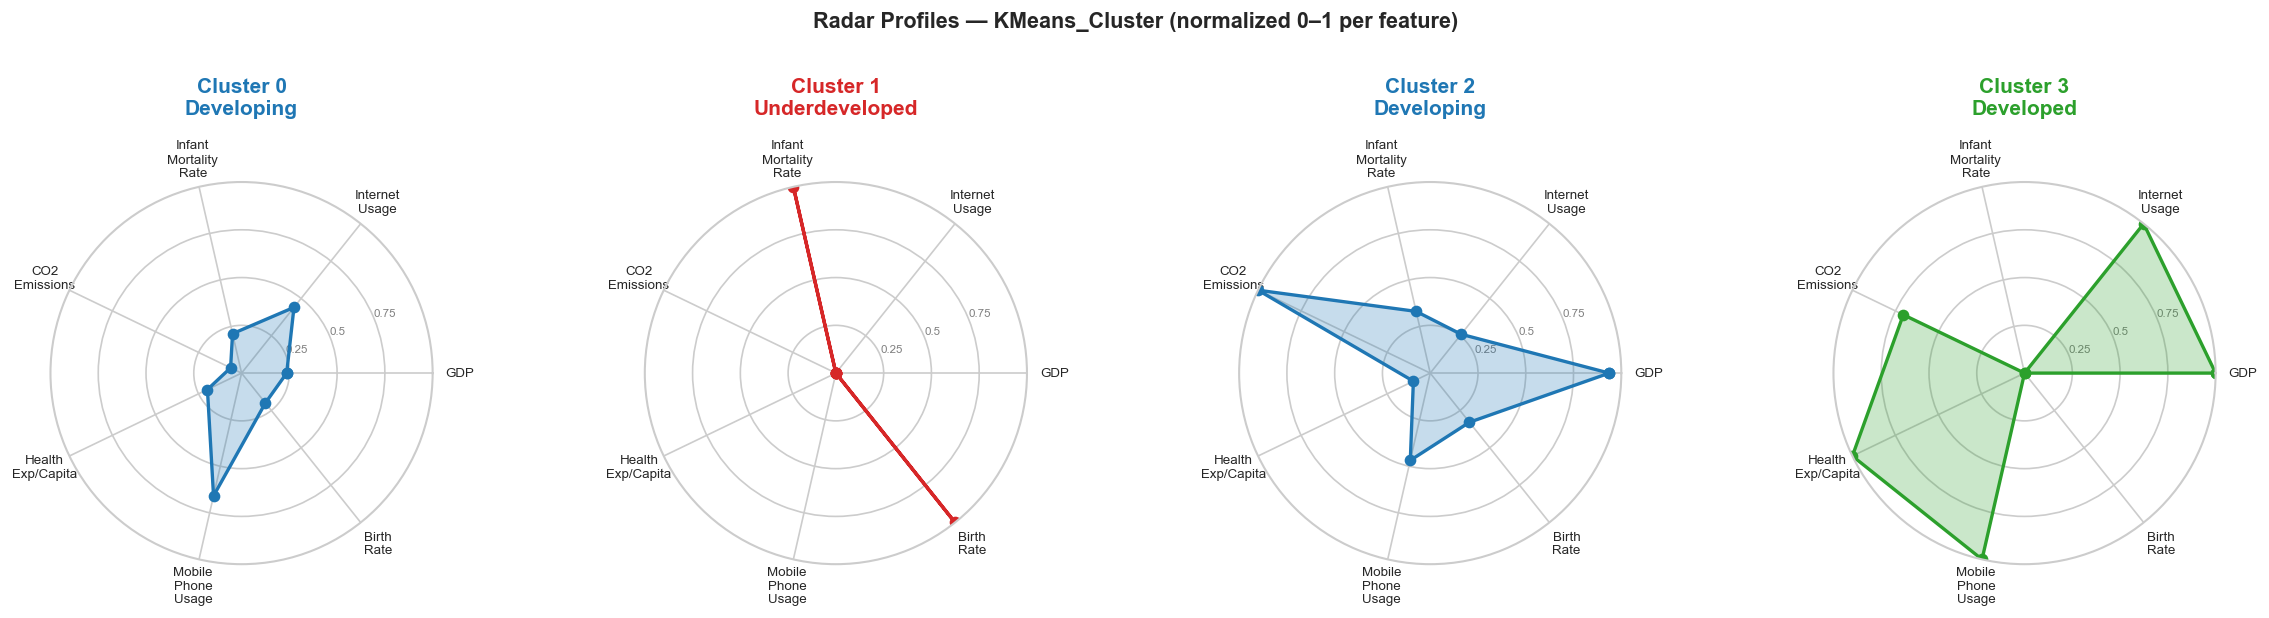

In [6]:
# ── Radar chart — top 8 most discriminating features ─────────────────────────
RADAR_FEATURES_RAW = [
    'GDP', 'Life Expectancy Female', 'Internet Usage',
    'Infant Mortality Rate', 'CO2 Emissions',
    'Health Exp/Capita', 'Mobile Phone Usage', 'Birth Rate',
]
# Use scaled version from df_out where possible, fall back to available feat_cols
radar_feats = [f for f in RADAR_FEATURES_RAW if f in feat_cols]
if len(radar_feats) < 3:
    radar_feats = feat_cols[:8]

N        = len(radar_feats)
angles   = [n / float(N) * 2 * pi for n in range(N)]
angles  += angles[:1]  # close the polygon

profile_best_raw = df_out.groupby(best_col)[radar_feats].mean()
n_clusters       = len(profile_best_raw)

# Normalize to [0,1] for radar readability
pmin = profile_best_raw.min()
pmax = profile_best_raw.max()
p_range = (pmax - pmin).replace(0, 1)
profile_norm = (profile_best_raw - pmin) / p_range

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5),
                          subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]

for ax, (cluster_id, row) in zip(axes, profile_norm.iterrows()):
    values  = row.tolist()
    values += values[:1]

    label_name = cluster_label_map.get(cluster_id, str(cluster_id))
    color      = LABEL_COLORS.get(label_name, PALETTE[cluster_id % 10])

    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace(' ', '\n') for f in radar_feats], size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.5','0.75'], size=7, color='grey')
    ax.set_title(f'Cluster {cluster_id}\n{label_name}', fontweight='bold', pad=15,
                 color=color)

plt.suptitle(f'Radar Profiles — {best_col} (normalized 0–1 per feature)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

---
## 6. Country Lists per Cluster (All 5 Models)

In [7]:
# ── Country membership per cluster for each model ────────────────────────────
for col in CLUSTER_COLS:
    label_col  = f'{col}_Label'
    model_name = col.replace('_Cluster', '')
    print('=' * 65)
    print(f'  {model_name}')
    print('=' * 65)

    for cluster_id in sorted(df_out[col].unique()):
        label_name = label_maps[col].get(cluster_id, str(cluster_id))
        mask       = df_out[col] == cluster_id
        ctrs       = df_out.loc[mask, ID_COL].sort_values().tolist() if ID_COL in df_out.columns else []
        n          = len(ctrs)
        color_tag  = {'Developed': '🟢', 'Developing': '🔵', 'Underdeveloped': '🔴'}.get(label_name, '⚪')

        print(f'  {color_tag} Cluster {cluster_id} — {label_name} ({n} countries):')
        # Print in rows of 5
        for i in range(0, len(ctrs), 5):
            print('    ' + ' | '.join(f'{c:<28}' for c in ctrs[i:i+5]))
    print()

  KMeans
  🔵 Cluster 0 — Developing (72 countries):
    Albania                      | Andorra                      | Antigua and Barbuda          | Armenia                      | Aruba                       
    Azerbaijan                   | Bahamas                      | Bahrain                      | Barbados                     | Bermuda                     
    Bosnia and Herzegovina       | Botswana                     | Brunei                       | Bulgaria                     | Chile                       
    Costa Rica                   | Croatia                      | Cuba                         | Cyprus                       | Dominica                    
    Dominican Republic           | Ecuador                      | El Salvador                  | Estonia                      | Faroe Islands               
    Fiji                         | French Polynesia             | Gabon                        | Georgia                      | Greenland                   
    Gr

In [8]:
# ── Notable country deep dive ─────────────────────────────────────────────────
SPOTLIGHT = ['United States', 'China', 'India', 'Germany', 'Nigeria',
             'Brazil', 'Somalia', 'Norway', 'Bangladesh']
spotlight_present = [c for c in SPOTLIGHT if ID_COL in df_out.columns
                     and c in df_out[ID_COL].values]

if spotlight_present:
    spotlight_df = df_out[df_out[ID_COL].isin(spotlight_present)][
        [ID_COL] + CLUSTER_COLS + [f'{c}_Label' for c in CLUSTER_COLS]
    ].set_index(ID_COL)
    print('Spotlight Countries — Cluster Assignments Across All Models:')
    display(spotlight_df)

Spotlight Countries — Cluster Assignments Across All Models:


,KMeans_Cluster,GMM_Cluster,Hierarchical_Cluster,Spectral_Cluster,Birch_Cluster,KMeans_Cluster_Label,GMM_Cluster_Label,Hierarchical_Cluster_Label,Spectral_Cluster_Label,Birch_Cluster_Label
Country,,,,,,,,,,
Bangladesh,2,1,2,2,3,Developing,Developing,Developed,Developing,Developing
Brazil,2,1,3,2,3,Developing,Developing,Developing,Developing,Developing
China,2,1,2,2,3,Developing,Developing,Developed,Developing,Developing
Germany,3,3,2,3,2,Developed,Developed,Developed,Developed,Developed
India,2,1,2,2,3,Developing,Developing,Developed,Developing,Developing
Nigeria,1,1,0,1,1,Underdeveloped,Developing,Developing,Underdeveloped,Underdeveloped
Norway,3,3,2,3,2,Developed,Developed,Developed,Developed,Developed
Somalia,1,2,0,1,1,Underdeveloped,Underdeveloped,Developing,Underdeveloped,Underdeveloped
United States,3,3,2,3,2,Developed,Developed,Developed,Developed,Developed


---
## 7. PCA 2D Scatter with Development Labels

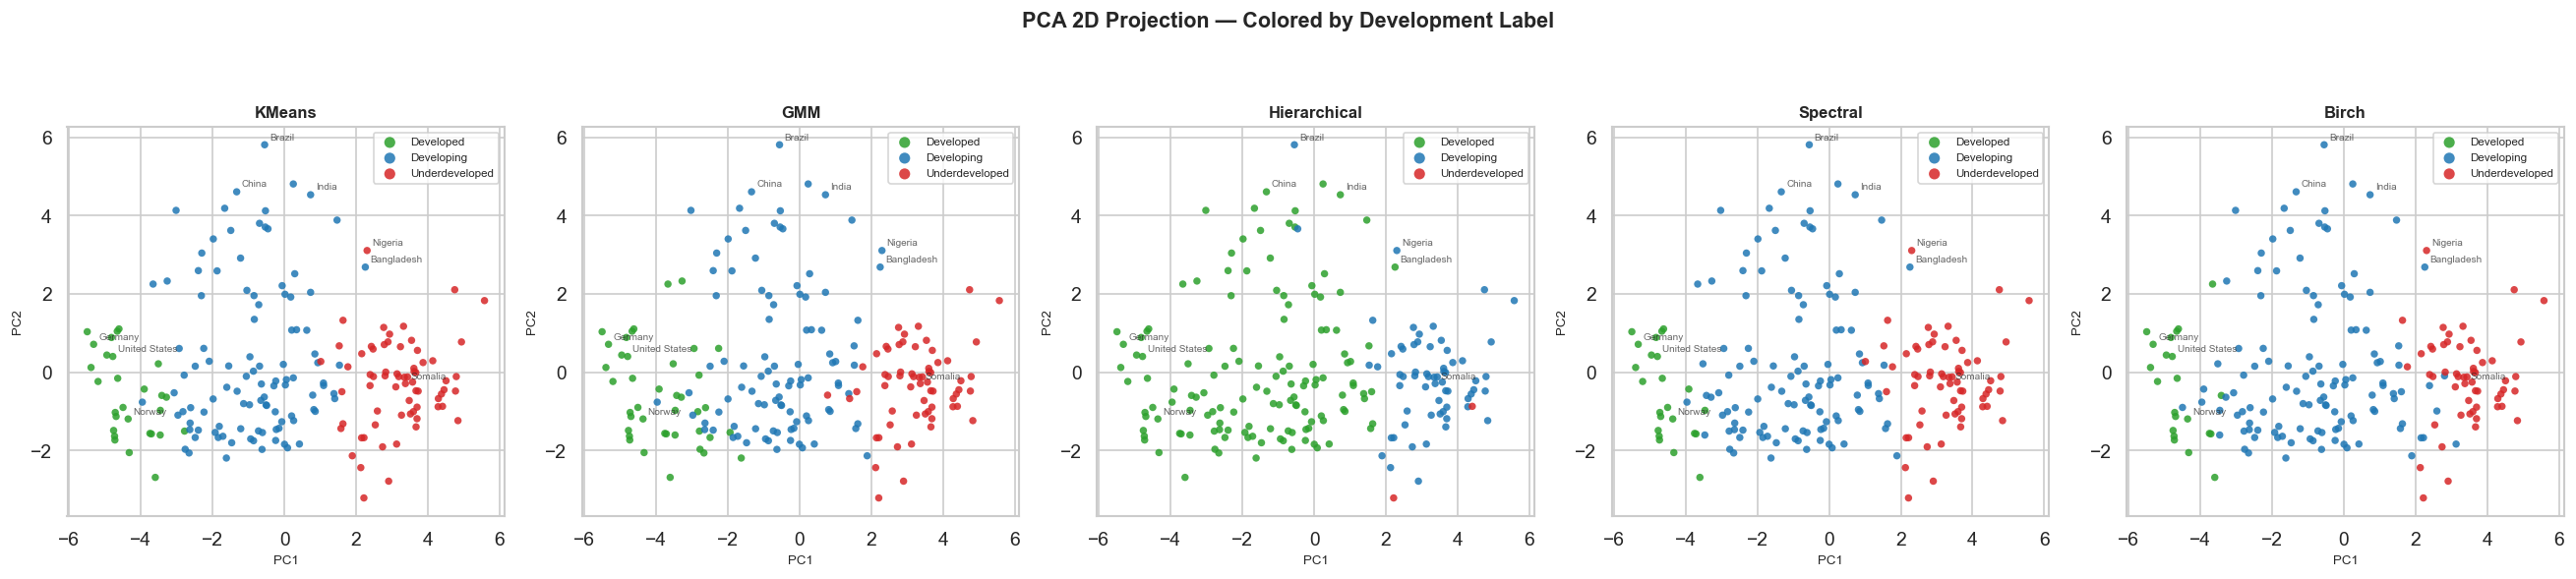

In [9]:
PCA_DATA_PATH = os.path.join(PROCESSED_DIR, 'pca_data.csv')
df_pca        = pd.read_csv(PCA_DATA_PATH)

if 'PC1' in df_pca.columns and 'PC2' in df_pca.columns:
    pc1 = df_pca['PC1'].values
    pc2 = df_pca['PC2'].values

    # Merge labels
    if ID_COL in df_pca.columns and ID_COL in df_out.columns:
        df_pca_merged = df_pca.merge(df_out[[ID_COL] + CLUSTER_COLS +
                                             [f'{c}_Label' for c in CLUSTER_COLS]],
                                     on=ID_COL, how='left')
    else:
        df_pca_merged = df_pca.copy()
        for col in CLUSTER_COLS:
            df_pca_merged[col] = df_out[col].values
            df_pca_merged[f'{col}_Label'] = df_out[f'{col}_Label'].values

    # ── 5-panel scatter colored by development label ──────────────────────────
    fig, axes = plt.subplots(1, len(CLUSTER_COLS), figsize=(22, 5))
    if len(CLUSTER_COLS) == 1:
        axes = [axes]

    for ax, col in zip(axes, CLUSTER_COLS):
        label_col = f'{col}_Label'
        if label_col not in df_pca_merged.columns:
            continue

        for lbl in LABEL_ORDER:
            mask = df_pca_merged[label_col] == lbl
            if mask.any():
                ax.scatter(df_pca_merged.loc[mask, 'PC1'],
                           df_pca_merged.loc[mask, 'PC2'],
                           c=LABEL_COLORS.get(lbl, '#888'),
                           label=lbl, s=20, alpha=0.85, edgecolors='none')

        # Annotate spotlight countries
        if ID_COL in df_pca_merged.columns:
            for _, row in df_pca_merged[df_pca_merged[ID_COL].isin(spotlight_present)].iterrows():
                ax.annotate(row[ID_COL], (row['PC1'], row['PC2']),
                            fontsize=6, alpha=0.7,
                            xytext=(3, 3), textcoords='offset points')

        model_name = col.replace('_Cluster', '')
        ax.set_title(model_name, fontweight='bold', fontsize=10)
        ax.set_xlabel('PC1', fontsize=8)
        ax.set_ylabel('PC2', fontsize=8)
        ax.legend(fontsize=7, markerscale=1.5)

    plt.suptitle('PCA 2D Projection — Colored by Development Label',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
else:
    print('⚠  PCA data not found — run notebook 03 first')

---
## 8. Agreement Analysis — How Often Do Models Agree?

In [10]:
# ── Label-level agreement (Developed / Developing / Underdeveloped) ───────────
label_cols_all = [f'{c}_Label' for c in CLUSTER_COLS if f'{c}_Label' in df_out.columns]

# Full agreement: all 5 models assign the same label
df_labels_only = df_out[label_cols_all].copy()
df_labels_only.index = countries

agreement_series = df_labels_only.apply(lambda row: len(set(row.dropna())) == 1, axis=1)
n_full_agree     = int(agreement_series.sum())
pct_full_agree   = n_full_agree / len(df_labels_only) * 100

print(f'Full agreement (all models same label) : {n_full_agree}/{len(df_labels_only)} countries ({pct_full_agree:.1f}%)')

# Majority vote label
from statistics import mode
def safe_mode(row):
    vals = [v for v in row if pd.notna(v)]
    try:
        return mode(vals)
    except Exception:
        return vals[0] if vals else np.nan

df_out['Majority_Label'] = df_labels_only.apply(safe_mode, axis=1)
df_out['Label_Agreement'] = df_labels_only.apply(
    lambda row: len(set(row.dropna())) == 1, axis=1
).map({True: 'Full', False: 'Partial'})

print(f'\nMajority vote label distribution:')
print(df_out['Majority_Label'].value_counts().to_string())

Full agreement (all models same label) : 25/198 countries (12.6%)

Majority vote label distribution:
Series([], )


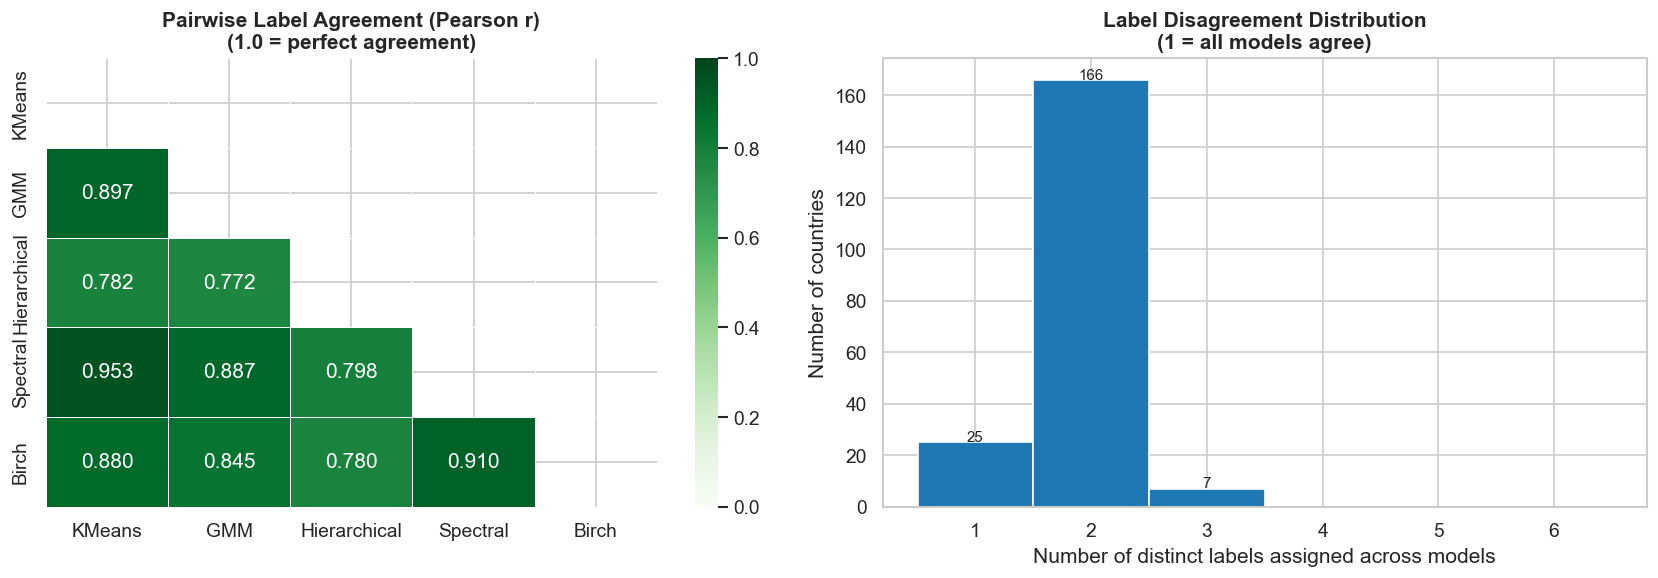


Disputed countries (0) — models disagree on label:


,Country,KMeans_Cluster_Label,GMM_Cluster_Label,Hierarchical_Cluster_Label,Spectral_Cluster_Label,Birch_Cluster_Label,Majority_Label


In [11]:
# ── Agreement heatmap: pairwise label correlation ─────────────────────────────
# Encode labels as int for correlation
label_int_map = {'Underdeveloped': 0, 'Developing': 1, 'Developed': 2}

label_int_df = df_labels_only.apply(lambda col: col.map(label_int_map))
corr_labels  = label_int_df.corr()
corr_labels.columns = [c.replace('_Cluster_Label', '') for c in corr_labels.columns]
corr_labels.index   = corr_labels.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairwise correlation
mask = np.triu(np.ones_like(corr_labels, dtype=bool))
sns.heatmap(corr_labels, mask=mask, annot=True, fmt='.3f', cmap='Greens',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pairwise Label Agreement (Pearson r)\n(1.0 = perfect agreement)', fontweight='bold')

# Agreement distribution
n_unique_labels = df_labels_only.apply(lambda row: len(set(row.dropna())), axis=1)
axes[1].hist(n_unique_labels, bins=range(1, len(label_cols_all) + 3), color=PALETTE[0],
             edgecolor='white', align='left')
axes[1].set_xticks(range(1, len(label_cols_all) + 2))
axes[1].set_xlabel('Number of distinct labels assigned across models')
axes[1].set_ylabel('Number of countries')
axes[1].set_title('Label Disagreement Distribution\n(1 = all models agree)', fontweight='bold')
for n in range(1, len(label_cols_all) + 2):
    cnt = int((n_unique_labels == n).sum())
    if cnt > 0:
        axes[1].text(n, cnt + 0.3, str(cnt), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Countries with disagreement ───────────────────────────────────────────────
disputed = df_out[df_out['Label_Agreement'] == 'Partial'][[ID_COL] + label_cols_all + ['Majority_Label']]
print(f'\nDisputed countries ({len(disputed)}) — models disagree on label:')
display(disputed.sort_values(ID_COL).reset_index(drop=True))

---
## 9. World Map Visualization

In [12]:
# ── Try Plotly choropleth (preferred) ─────────────────────────────────────────
try:
    import plotly.express as px
    import plotly.graph_objects as go

    best_label_col = f'{best_col}_Label'

    if ID_COL in df_out.columns and best_label_col in df_out.columns:
        df_map = df_out[[ID_COL, best_label_col, best_col, 'Majority_Label']].copy()

        color_map = {'Developed': '#2ca02c', 'Developing': '#1f77b4', 'Underdeveloped': '#d62728'}

        fig = px.choropleth(
            df_map,
            locations=ID_COL,
            locationmode='country names',
            color=best_label_col,
            color_discrete_map=color_map,
            title=f'World Development Clusters — {best_col}<br><sup>Green=Developed | Blue=Developing | Red=Underdeveloped</sup>',
            hover_name=ID_COL,
            hover_data={best_col: True, best_label_col: True},
            category_orders={best_label_col: ['Developed', 'Developing', 'Underdeveloped']},
        )
        fig.update_layout(
            geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
            legend_title_text='Development Status',
            height=500,
            margin=dict(l=0, r=0, t=60, b=0),
        )
        fig.show()

        # ── Majority vote map ─────────────────────────────────────────────────
        fig2 = px.choropleth(
            df_map,
            locations=ID_COL,
            locationmode='country names',
            color='Majority_Label',
            color_discrete_map=color_map,
            title='World Development Clusters — Majority Vote Across All 5 Models',
            hover_name=ID_COL,
            category_orders={'Majority_Label': ['Developed', 'Developing', 'Underdeveloped']},
        )
        fig2.update_layout(
            geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
            legend_title_text='Development Status (Majority)',
            height=500,
            margin=dict(l=0, r=0, t=60, b=0),
        )
        fig2.show()

    print('✅ Plotly choropleth maps rendered')

except ImportError:
    print('Plotly not available — falling back to matplotlib world map')

    # ── Matplotlib fallback: bar chart by continent region (approximate) ──────
    REGION_MAP = {
        'United States': 'N. America', 'Canada': 'N. America', 'Mexico': 'N. America',
        'Brazil': 'S. America', 'Argentina': 'S. America', 'Colombia': 'S. America',
        'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe',
        'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia',
        'Nigeria': 'Africa', 'Ethiopia': 'Africa', 'Kenya': 'Africa', 'Egypt': 'Africa',
        'Australia': 'Oceania', 'New Zealand': 'Oceania',
    }
    best_label_col = f'{best_col}_Label'
    if ID_COL in df_out.columns and best_label_col in df_out.columns:
        df_reg = df_out[[ID_COL, best_label_col]].copy()
        df_reg['Region'] = df_reg[ID_COL].map(REGION_MAP).fillna('Other')
        ct = pd.crosstab(df_reg['Region'], df_reg[best_label_col])
        ct.plot(kind='bar', color=[LABEL_COLORS.get(c,'grey') for c in ct.columns],
                figsize=(12, 5), edgecolor='white')
        plt.title('Development Label by Region (known countries)', fontweight='bold')
        plt.xlabel('Region')
        plt.ylabel('Countries')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

✅ Plotly choropleth maps rendered


---
## 10. Final Report Summary

Cluster Profiles — Original-Scale Indicators:


,GDP,Life Expectancy Female,Internet Usage,Infant Mortality Rate,CO2 Emissions
KMeans_Cluster_Label,,,,,
Developed,1.239839e+12,82.29,0.60,0.00,406220.31
Developing,1.512624e+11,75.54,0.26,0.02,158599.48
Underdeveloped,1.053806e+10,59.43,0.04,0.06,6717.45


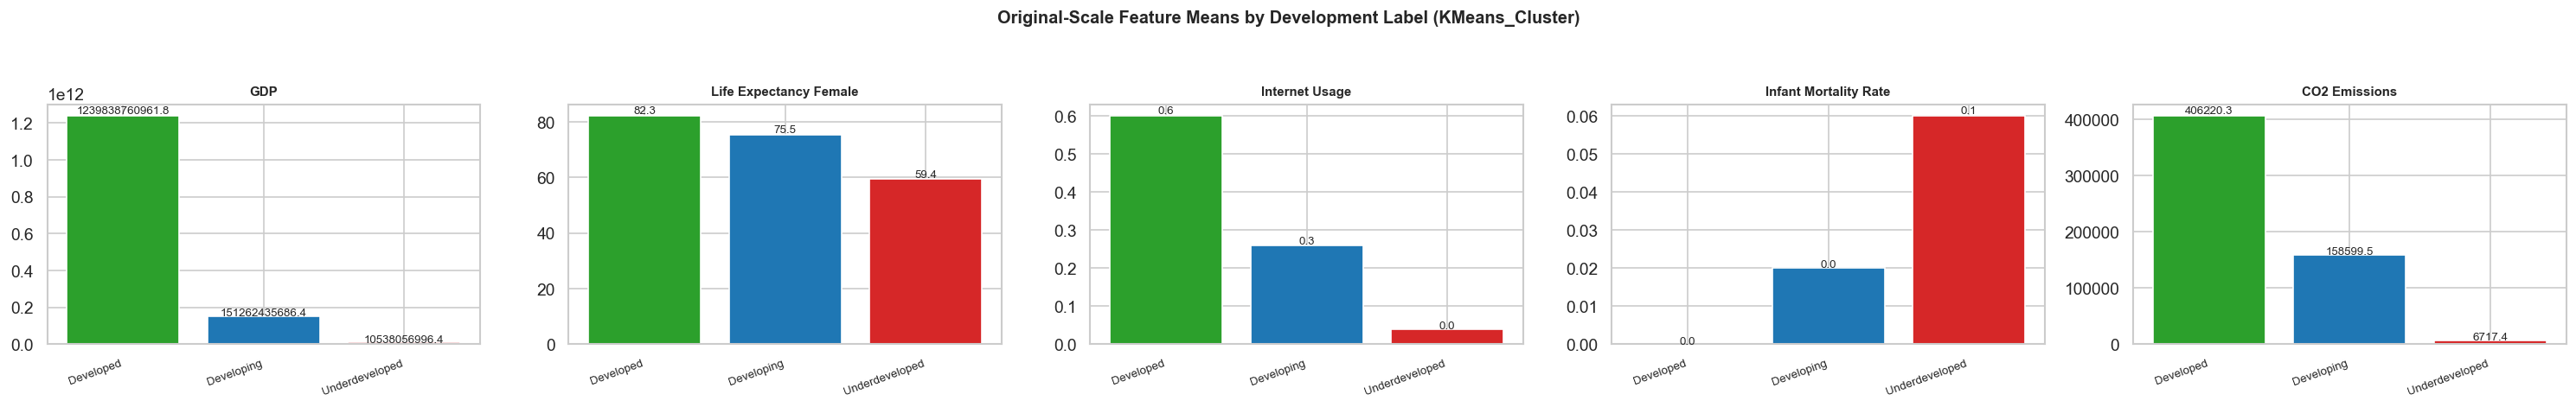

In [13]:
# ── Cluster profile summary table (original-scale indicators) ─────────────────
SUMMARY_FEATS_RAW = ['GDP', 'Life Expectancy Female', 'Internet Usage',
                     'Infant Mortality Rate', 'CO2 Emissions']
summary_feats = [f for f in SUMMARY_FEATS_RAW if f in df_cleaned.columns]

if summary_feats and ID_COL in df_out.columns and ID_COL in df_cleaned.columns:
    best_label_col = f'{best_col}_Label'
    df_summary = df_out[[ID_COL, best_col, best_label_col]].merge(
        df_cleaned[[ID_COL] + summary_feats], on=ID_COL, how='left'
    )
    profile_orig = df_summary.groupby(best_label_col)[summary_feats].mean().round(2)
    profile_orig = profile_orig.reindex([l for l in LABEL_ORDER if l in profile_orig.index])

    print('Cluster Profiles — Original-Scale Indicators:')
    display(profile_orig)

    # ── Grouped bar chart ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(summary_feats), figsize=(5 * len(summary_feats), 4))
    if len(summary_feats) == 1:
        axes = [axes]

    for ax, feat in zip(axes, summary_feats):
        labels_present = [l for l in LABEL_ORDER if l in profile_orig.index]
        vals   = [profile_orig.loc[l, feat] for l in labels_present]
        colors = [LABEL_COLORS.get(l, '#888') for l in labels_present]
        ax.bar(labels_present, vals, color=colors, edgecolor='white')
        ax.set_title(feat, fontweight='bold', fontsize=9)
        ax.set_xticklabels(labels_present, rotation=20, ha='right', fontsize=8)
        for i, v in enumerate(vals):
            ax.text(i, v * 1.01, f'{v:.1f}', ha='center', fontsize=8)

    plt.suptitle(f'Original-Scale Feature Means by Development Label ({best_col})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [14]:
# ── Save final clustered dataframe ────────────────────────────────────────────
df_out.to_csv(CLUSTERED_DATA, index=False)
print(f'✅ final_clustered_data.csv saved | shape: {df_out.shape}')

# ── Pipeline completion summary ───────────────────────────────────────────────
print()
print('=' * 70)
print('WORLD DEVELOPMENT CLUSTERING — PIPELINE COMPLETE')
print('=' * 70)
print(f'  Countries profiled   : {len(df_out)}')
print(f'  Features used        : {len(feat_cols)}')
print(f'  Models trained       : 5 (KMeans, GMM, Agglomerative, Spectral, BIRCH)')
print(f'  Best model           : {best_col.replace("_Cluster","")}')
print(f'  Trend features       : {len([c for c in feat_cols if "_trend" in c])} (GDP, Internet, CO2, LifeExp, Mobile)')
print()
print('  Label Summary (Best Model — Original Scale):')
if 'profile_orig' in dir():
    for lbl in LABEL_ORDER:
        if lbl in profile_orig.index:
            n = int((df_out[f'{best_col}_Label'] == lbl).sum())
            tag = {'Developed':'🟢','Developing':'🔵','Underdeveloped':'🔴'}.get(lbl,'⚪')
            print(f'  {tag}  {lbl:<18}: {n:>3} countries')
print()
print('  Artifacts:')
artifacts = [
    CLUSTERED_DATA,
    os.path.join(REPORTS_DIR, f'cluster_profiles_{best_col}.csv'),
    os.path.join(REPORTS_DIR, 'evaluation_metrics.json'),
]
for path in artifacts:
    exists = '✅' if os.path.exists(path) else '❌'
    print(f'  {exists}  {path}')
print('=' * 70)

✅ final_clustered_data.csv saved | shape: (198, 33)

WORLD DEVELOPMENT CLUSTERING — PIPELINE COMPLETE
  Countries profiled   : 198
  Features used        : 20
  Models trained       : 5 (KMeans, GMM, Agglomerative, Spectral, BIRCH)
  Best model           : KMeans
  Trend features       : 4 (GDP, Internet, CO2, LifeExp, Mobile)

  Label Summary (Best Model — Original Scale):
  🟢  Developed         :  28 countries
  🔵  Developing        : 103 countries
  🔴  Underdeveloped    :  67 countries

  Artifacts:
  ✅  c:\Users\graj2\Data Science\Projects\World-Development-Clustering\data\processed\final_clustered_data.csv
  ✅  c:\Users\graj2\Data Science\Projects\World-Development-Clustering\reports\cluster_profiles_KMeans_Cluster.csv
  ✅  c:\Users\graj2\Data Science\Projects\World-Development-Clustering\reports\evaluation_metrics.json
